In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from churn_prediction.paths import PROCESSED_DIR, FEATURES_DIR

All directories created successfully!


In [6]:
print("\n1. ĐỌC DỮ LIỆU FEATURES")
# Đọc bảng features đã được tạo từ feature_engineering.ipynb
features_df = pd.read_parquet(FEATURES_DIR / 'customer_features.parquet')
print(f"   Features shape: {features_df.shape}")
print(f"   Số khách hàng: {len(features_df):,}")


1. ĐỌC DỮ LIỆU FEATURES
   Features shape: (96136, 44)
   Số khách hàng: 96,136


In [8]:
print("\n2. TẠO NHÃN TRẢI NGHIỆM KHÁCH HÀNG")

# Kiểm tra các cột cần thiết có tồn tại không
required_cols = ['avg_review_score', 'late_delivery_ratio']
missing = [c for c in required_cols if c not in features_df.columns]
if missing:
    raise ValueError(f"Thiếu cột: {missing}. Hãy chạy feature_engineering.ipynb trước.")

# Chuẩn hóa các thành phần
# review_score: 1-5 -> 0-1
features_df['review_norm'] = (features_df['avg_review_score'] - 1) / 4

# late_delivery_ratio: 0-1 -> đảo chiều (1 - tỷ lệ trễ)
features_df['delivery_norm'] = 1 - features_df['late_delivery_ratio']

# low_review_ratio (nếu có)
if 'low_review_ratio' in features_df.columns:
    features_df['low_review_norm'] = 1 - features_df['low_review_ratio']
else:
    features_df['low_review_norm'] = 1.0  # mặc định tốt

# avg_delivery_delay (nếu có)
if 'avg_delivery_delay' in features_df.columns:
    max_delay = features_df['avg_delivery_delay'].quantile(0.95)
    features_df['delay_norm'] = 1 - np.clip(features_df['avg_delivery_delay'] / max_delay, 0, 1)
else:
    features_df['delay_norm'] = 1.0

# Tính điểm tổng hợp (có thể điều chỉnh trọng số)
features_df['experience_score'] = (
    0.5 * features_df['review_norm'] +
    0.3 * features_df['delivery_norm'] +
    0.1 * features_df['low_review_norm'] +
    0.1 * features_df['delay_norm']
) * 10  # thang 0-10

# Phân loại level
def classify_exp(score):
    if score >= 8:
        return 'excellent'
    elif score >= 6:
        return 'good'
    elif score >= 4:
        return 'average'
    else:
        return 'poor'

features_df['experience_level'] = features_df['experience_score'].apply(classify_exp)

# Thống kê
print("\n   Phân phối experience_score:")
print(features_df['experience_score'].describe())
print("\n   Phân phối experience_level (%):")
print(features_df['experience_level'].value_counts(normalize=True).mul(100).round(2))


2. TẠO NHÃN TRẢI NGHIỆM KHÁCH HÀNG

   Phân phối experience_score:
count    96136.000000
mean         8.445254
std          2.493261
min          0.000000
25%          7.500000
50%         10.000000
75%         10.000000
max         10.000000
Name: experience_score, dtype: float64

   Phân phối experience_level (%):
experience_level
excellent    74.03
good         10.63
average      10.43
poor          4.90
Name: proportion, dtype: float64



3. VẼ BIỂU ĐỒ


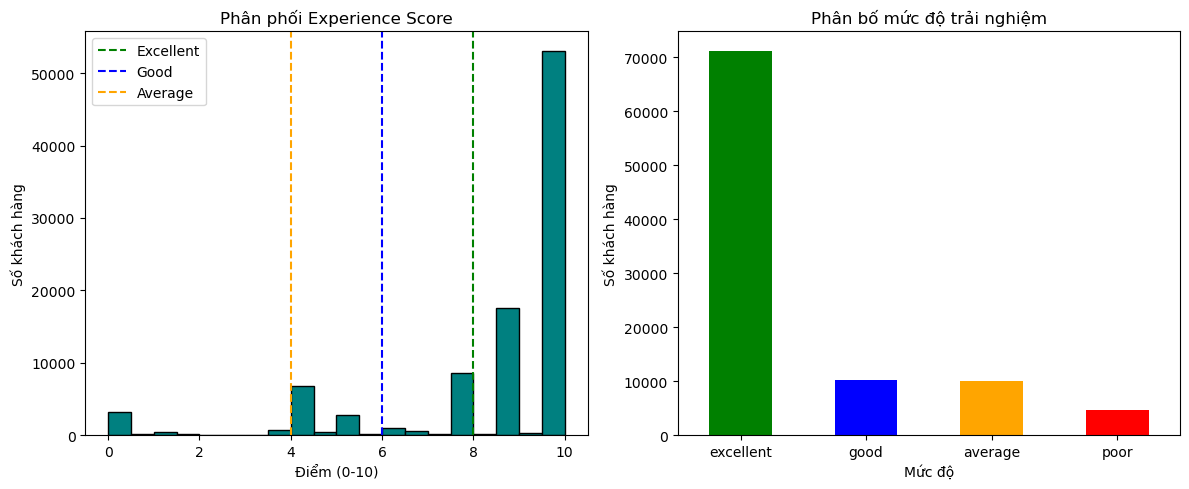

In [9]:
print("\n3. VẼ BIỂU ĐỒ")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(features_df['experience_score'], bins=20, color='teal', edgecolor='black')
plt.axvline(8, color='green', linestyle='--', label='Excellent')
plt.axvline(6, color='blue', linestyle='--', label='Good')
plt.axvline(4, color='orange', linestyle='--', label='Average')
plt.title('Phân phối Experience Score')
plt.xlabel('Điểm (0-10)')
plt.ylabel('Số khách hàng')
plt.legend()

plt.subplot(1, 2, 2)
level_counts = features_df['experience_level'].value_counts()
level_counts.plot(kind='bar', color=['green', 'blue', 'orange', 'red'])
plt.title('Phân bố mức độ trải nghiệm')
plt.xlabel('Mức độ')
plt.ylabel('Số khách hàng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
print("\n4. LƯU KẾT QUẢ")

# Lưu bảng features đã có nhãn
features_df.to_parquet(FEATURES_DIR / 'customer_features_labeled.parquet', index=False)
print(f"Đã lưu customer_features_labeled.parquet")

# Lưu metadata
metadata = {
    'experience_score_range': [0, 10],
    'experience_levels': features_df['experience_level'].value_counts().to_dict(),
    'formula_weights': {
        'review': 0.5,
        'delivery': 0.3,
        'low_review': 0.1,
        'delay': 0.1
    },
    'date_processed': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}
with open(FEATURES_DIR / 'experience_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Đã lưu experience_metadata.json")

print("\n=== HOÀN TẤT TẠO NHÃN TRẢI NGHIỆM ===")


4. LƯU KẾT QUẢ
Đã lưu customer_features_labeled.parquet
Đã lưu experience_metadata.json

=== HOÀN TẤT TẠO NHÃN TRẢI NGHIỆM ===
